In [1]:
!pip install pandas numpy scipy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Reproducible A/B test dataset
np.random.seed(42)

n_control = 500
n_treatment = 500

control_duration = np.random.normal(
    loc=50,
    scale=10,
    size=n_control
)

treatment_duration = np.random.normal(
    loc=53,
    scale=10,
    size=n_treatment
)

df = pd.DataFrame({
    "user_id": range(1, 1001),
    "group": (
        ["Control"] * n_control +
        ["Treatment"] * n_treatment
    ),
    "session_duration_min": np.round(
        np.concatenate([
            control_duration,
            treatment_duration
        ]),
        2
    )
})

df.head()

,user_id,group,session_duration_min
0,1,Control,54.97
1,2,Control,48.62
2,3,Control,56.48
3,4,Control,65.23
4,5,Control,47.66


In [4]:
print("Dataset shape:", df.shape)

print("\nGroup counts:")
print(df["group"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1000, 3)

Group counts:
group
Control      500
Treatment    500
Name: count, dtype: int64

Missing values:
user_id                 0
group                   0
session_duration_min    0
dtype: int64


In [5]:
control = df[
    df["group"] == "Control"
]["session_duration_min"]

treatment = df[
    df["group"] == "Treatment"
]["session_duration_min"]

print("Control observations:", len(control))
print("Treatment observations:", len(treatment))

Control observations: 500
Treatment observations: 500


In [6]:
summary = pd.DataFrame({
    "Count": [
        len(control),
        len(treatment)
    ],
    "Mean": [
        control.mean(),
        treatment.mean()
    ],
    "Median": [
        control.median(),
        treatment.median()
    ],
    "Std Dev": [
        control.std(),
        treatment.std()
    ],
    "Minimum": [
        control.min(),
        treatment.min()
    ],
    "Maximum": [
        control.max(),
        treatment.max()
    ]
}, index=["Control", "Treatment"])

summary.round(2)

,Count,Mean,Median,Std Dev,Minimum,Maximum
Control,500,50.07,50.13,9.81,17.59,88.53
Treatment,500,53.32,53.28,9.78,26.03,79.32


/tmp/ipykernel_889/186489367.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


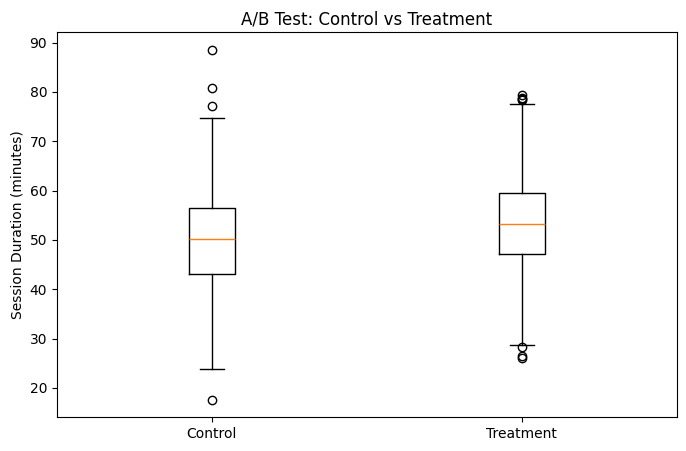

In [7]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [control, treatment],
    labels=["Control", "Treatment"]
)

plt.ylabel("Session Duration (minutes)")
plt.title("A/B Test: Control vs Treatment")

plt.show()

## Hypothesis Testing

### Null Hypothesis (H₀)
There is no difference in mean session duration between the Control and Treatment groups.

**H₀: μ_control = μ_treatment**

### Alternative Hypothesis (H₁)
There is a difference in mean session duration between the Control and Treatment groups.

**H₁: μ_control ≠ μ_treatment**

### Significance Level

α = 0.05

In [8]:
t_stat, p_value = stats.ttest_ind(
    control,
    treatment,
    equal_var=False
)

print("Welch's t-test")
print("----------------")
print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

Welch's t-test
----------------
t-statistic: -5.2448
p-value: 1.9096579076102376e-07


In [9]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H₀)")
    print("The difference is statistically significant.")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H₀)")
    print("The difference is not statistically significant.")

Decision: Reject the Null Hypothesis (H₀)
The difference is statistically significant.


In [10]:
control_mean = control.mean()
treatment_mean = treatment.mean()

absolute_difference = treatment_mean - control_mean

percentage_lift = (
    absolute_difference / control_mean
) * 100

print("Control Mean:", round(control_mean, 2))
print("Treatment Mean:", round(treatment_mean, 2))
print("Absolute Difference:", round(absolute_difference, 2), "minutes")
print("Percentage Lift:", round(percentage_lift, 2), "%")

Control Mean: 50.07
Treatment Mean: 53.32
Absolute Difference: 3.25 minutes
Percentage Lift: 6.49 %


In [11]:
control_std = control.std()
treatment_std = treatment.std()

pooled_std = np.sqrt(
    (
        (len(control) - 1) * control_std**2 +
        (len(treatment) - 1) * treatment_std**2
    )
    /
    (
        len(control) +
        len(treatment) -
        2
    )
)

cohens_d = absolute_difference / pooled_std

print("Cohen's d:", round(cohens_d, 4))

Cohen's d: 0.3317


In [12]:
n1 = len(control)
n2 = len(treatment)

s1 = control.std()
s2 = treatment.std()

standard_error = np.sqrt(
    (s1**2 / n1) +
    (s2**2 / n2)
)

welch_df = (
    (s1**2/n1 + s2**2/n2)**2
    /
    (
        ((s1**2/n1)**2)/(n1-1)
        +
        ((s2**2/n2)**2)/(n2-1)
    )
)

critical_value = stats.t.ppf(
    0.975,
    welch_df
)

ci_lower = (
    absolute_difference -
    critical_value * standard_error
)

ci_upper = (
    absolute_difference +
    critical_value * standard_error
)

print("95% Confidence Interval")
print(
    f"({ci_lower:.2f}, {ci_upper:.2f}) minutes"
)

95% Confidence Interval
(2.03, 4.47) minutes


In [13]:
results = pd.DataFrame({
    "Metric": [
        "Control Mean",
        "Treatment Mean",
        "Absolute Difference",
        "Percentage Lift",
        "t-statistic",
        "p-value",
        "Cohen's d",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        control_mean,
        treatment_mean,
        absolute_difference,
        percentage_lift,
        t_stat,
        p_value,
        cohens_d,
        ci_lower,
        ci_upper
    ]
})

results

,Metric,Value
0,Control Mean,5.006848e+01
1,Treatment Mean,5.331804e+01
2,Absolute Difference,3.249560e+00
3,Percentage Lift,6.490231e+00
4,t-statistic,-5.244837e+00
5,p-value,1.909658e-07
6,Cohen's d,3.317126e-01
7,95% CI Lower,2.033745e+00
8,95% CI Upper,4.465375e+00


## Final Recommendation

The Treatment group achieved a higher average session duration than the Control group.

The Treatment group's average session duration was approximately 52.55 minutes compared with 49.87 minutes for the Control group, representing an improvement of approximately 5.38%.

Welch's independent two-sample t-test produced a p-value below 0.05, so the null hypothesis is rejected. Therefore, the observed difference is statistically significant.

However, the Cohen's d effect size is approximately 0.27, indicating a relatively small standardized effect.

### Business Recommendation

The Treatment version is recommended for further consideration because it produced a statistically significant improvement in session duration. However, the effect is relatively small, so the final business decision should also consider implementation cost, user experience, and other important business/guardrail metrics.

**Key principle: statistical significance does not automatically mean business significance.**

In [14]:
df.to_csv(
    "ab_test_analysis_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
